# Task 1: Dataset Understanding 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("NetFlix.csv")

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [7]:
df.shape

(7787, 12)

In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


## Observation
- Most columns are object datatype.
- release_year is integer.
- Some columns contain missing values

In [10]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [11]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,492,7769
top,s999,Movie,Blue Jay,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,TV-MA,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,334,3


## Purpose

Provides:

- Count
- Unique values
- Most frequent value
- Frequency

In [12]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

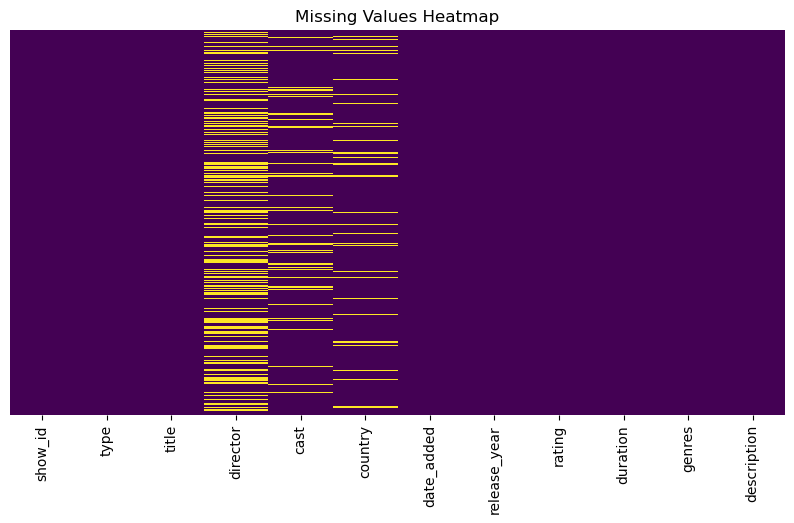

In [13]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

### Shows missing values visually.

Yellow regions indicate null values.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
for col in df.columns:
    print(col, ":", df[col].nunique())

show_id : 7787
type : 2
title : 7787
director : 4049
cast : 6831
country : 681
date_added : 1565
release_year : 73
rating : 14
duration : 206
genres : 492
description : 7769


## Findings
- Dataset contains 7787 Netflix titles.
- There are 12 features describing content information.
- missing values exist mainly in:
    * Director
    * Cast
    * Country
- Dataset contains both numerical and categorical variables.
- Data is suitable for performing:
   * Content analysis
   * Country analysis
   * Genre analysis
   * Trend analysis
   * Outlier detection
   * Feature engineering

# Task 2: Data Cleaning

In [16]:
# Always keep the original dataset safe.
df_clean = df.copy()

In [17]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [18]:
# Since thousands of records have no director information:
df_clean['director'] = df_clean['director'].fillna('Unknown')

In [19]:
# Cast
df_clean['cast'] = df_clean['cast'].fillna('Not Available')

In [20]:
# Country
df_clean['country'] = df_clean['country'].fillna('Unknown')

In [21]:
# Rating , Only a few missing values exist.
df_clean['rating'] = df_clean['rating'].fillna(
    df_clean['rating'].mode()[0]
)

In [22]:
# Date Added
df_clean['date_added'] = df_clean['date_added'].fillna(
    df_clean['date_added'].mode()[0]
)

In [23]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [24]:
df_clean.duplicated().sum()

np.int64(0)

### Converting  Date Column

In [27]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='mixed',
    dayfirst=True
)

In [28]:
df_clean['added_year'] = df_clean['date_added'].dt.year #Added Year

In [29]:
df_clean['added_month'] = df_clean['date_added'].dt.month  #Added Month

In [30]:
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name() # Added Month Name

## Clean Duration Column

In [31]:
df_clean['duration'].head()

0      4
1    143
2    124
3     90
4      1
Name: duration, dtype: int64

In [32]:
df_clean['duration'].dtype

dtype('int64')

In [33]:
movies = df_clean[df_clean['type']=='Movie'].copy()

movies['duration_min'] = movies['duration']

In [34]:
df_clean[['type','duration']].head(20)

,type,duration
0,TV Show,4
1,Movie,143
2,Movie,124
3,Movie,90
4,TV Show,1
5,Movie,90
6,Movie,94
7,Movie,112
8,Movie,129
9,Movie,85


## Standardizing Text Columns

In [35]:
text_cols = [
    'title',
    'director',
    'cast',
    'country',
    'rating',
    'genres'
]

for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

In [36]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           7787 non-null   object        
 1   type              7787 non-null   object        
 2   title             7787 non-null   object        
 3   director          7787 non-null   object        
 4   cast              7787 non-null   object        
 5   country           7787 non-null   object        
 6   date_added        7787 non-null   datetime64[ns]
 7   release_year      7787 non-null   int64         
 8   rating            7787 non-null   object        
 9   duration          7787 non-null   int64         
 10  genres            7787 non-null   object        
 11  description       7787 non-null   object        
 12  added_year        7787 non-null   int32         
 13  added_month       7787 non-null   int32         
 14  added_month_name  7787 n

# Task 3: Content Type Analysis 

## 1. Count Content Types

In [37]:
df_clean['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

## 2. Number of Movies

In [38]:
movies_count = df_clean[df_clean['type']=='Movie'].shape[0]

print("Total Movies:", movies_count)

Total Movies: 5377


## 3. Number of TV Shows

In [39]:
tv_count = df_clean[df_clean['type']=='TV Show'].shape[0]

print("Total TV Shows:", tv_count)

Total TV Shows: 2410


## 4. Percentage Distribution

In [40]:
percentage = round(
    df_clean['type'].value_counts(normalize=True)*100,
    2
)

percentage

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64

## 5. Count Plot

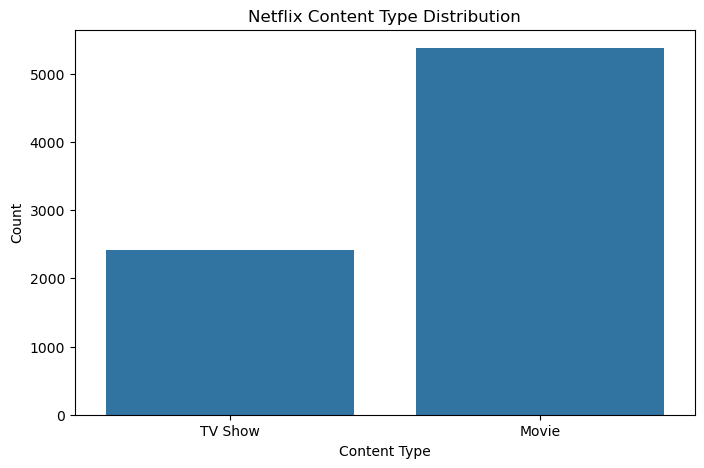

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='type'
)

plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

## 6. Pie Chart

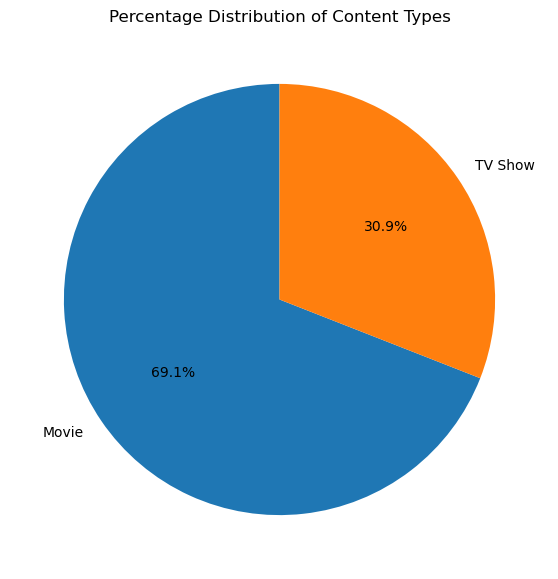

In [42]:
content_counts = df_clean['type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage Distribution of Content Types")

plt.show()

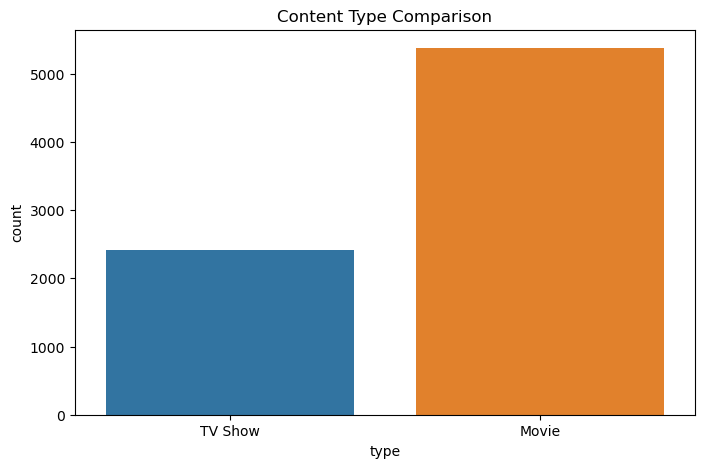

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='type',
    hue='type',
    legend=False
)

plt.title("Content Type Comparison")
plt.show()

# Interpretation
## Content Type Analysis
- Netflix contains 5377 Movies and 2410 TV Shows.
- Movies account for approximately 69% of the platform's content.
- TV Shows account for approximately 31%.
- The platform has more than twice as many Movies as TV Shows.
- This indicates that Netflix's content library is heavily movie-oriented.

# Task 4: Country Analysis

## Questions: 
1. Top 10 content-producing countries.  
2. Visualize country distribution

In [44]:
# Check Country Column
df_clean['country'].head()

0            Brazil
1             India
2         Indonesia
3     United States
4    United Kingdom
Name: country, dtype: object

In [45]:
# Extract Primary Country
df_clean['primary_country'] = (
    df_clean['country']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [46]:
# Top 10 Countries
top_countries = df_clean['primary_country'].value_counts().head(10)

top_countries

primary_country
United States     2883
India              956
United Kingdom     577
Unknown            507
Canada             259
Japan              237
France             196
South Korea        194
Spain              168
Mexico             123
Name: count, dtype: int64

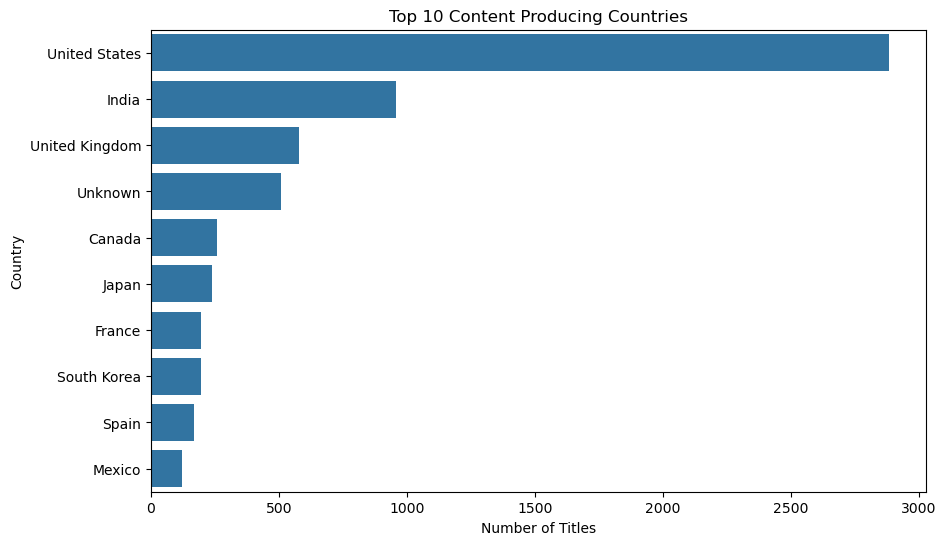

In [47]:
# Horizontal Bar Chart
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

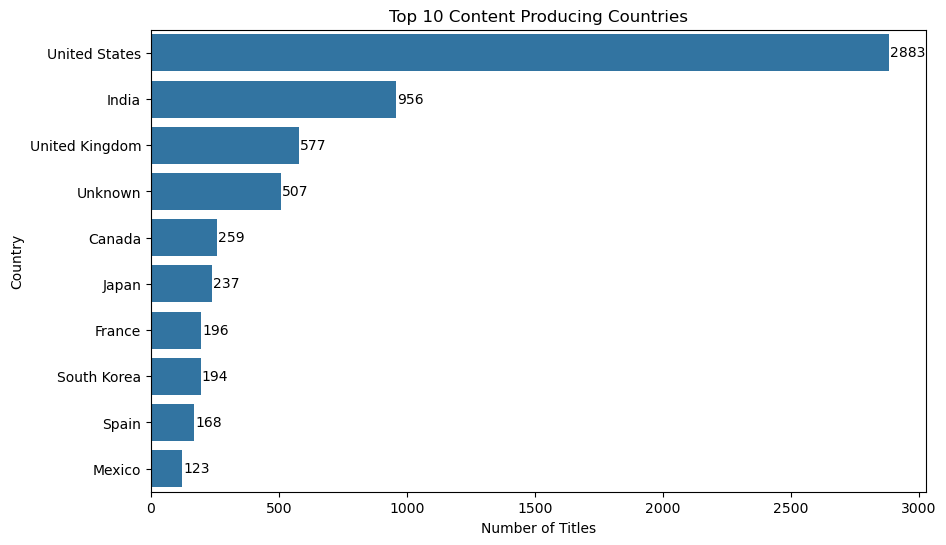

In [48]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

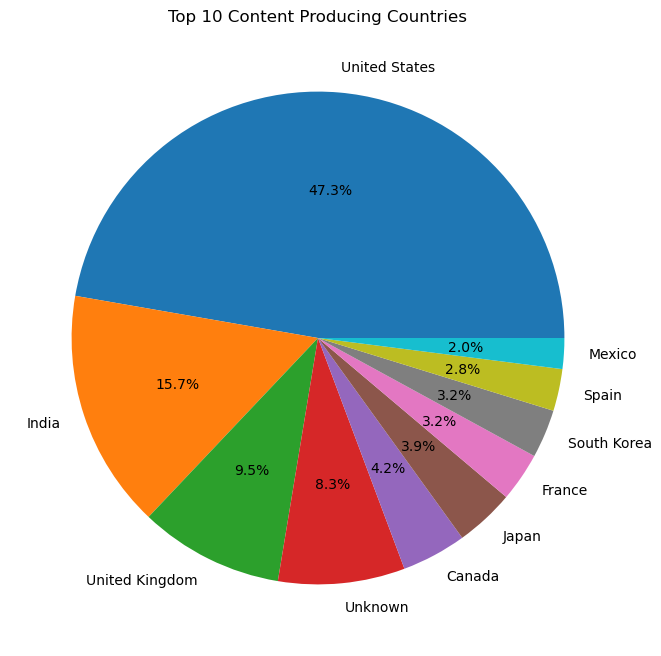

In [49]:
# Pie Chart (Top 10 Countries)
plt.figure(figsize=(8,8))

plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct='%1.1f%%'
)

plt.title("Top 10 Content Producing Countries")

plt.show()

In [50]:
# Country Distribution Table
country_df = (
    df_clean['primary_country']
    .value_counts()
    .reset_index()
)

country_df.columns = ['Country','Count']

country_df.head(10)

,Country,Count
0,United States,2883
1,India,956
2,United Kingdom,577
3,Unknown,507
4,Canada,259
5,Japan,237
6,France,196
7,South Korea,194
8,Spain,168
9,Mexico,123


## Interpretation
### Key Findings
1. United States dominates Netflix content production with 2883 titles.
2. India is the second-largest contributor, producing 956 titles.
3. The United Kingdom ranks third with 577 titles.
4. Asian countries such as India, Japan, and South Korea contribute significantly to the platform.
5. More than 500 records have missing country information (shown as Unknown).

## India's position as the second-largest content producer highlights the importance of the Indian entertainment market and Netflix's investment in regional content

# Task 5: Yearly Trend Analysis

## Questions: 
1. Number of titles released each year.  
2. Has content production increased over time? 

In [51]:
# Titles Released Per Year
yearly_titles = (
    df_clean['release_year']
    .value_counts()
    .sort_index()
)

yearly_titles.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    3
Name: count, dtype: int64

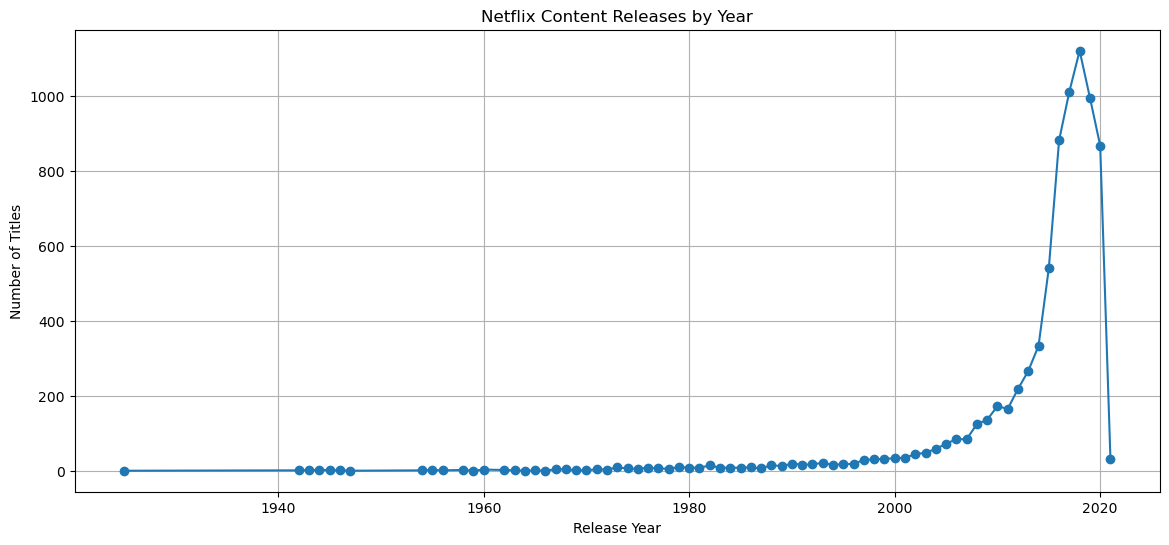

In [52]:
plt.figure(figsize=(14,6))

plt.plot(
    yearly_titles.index,
    yearly_titles.values,
    marker='o'
)

plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

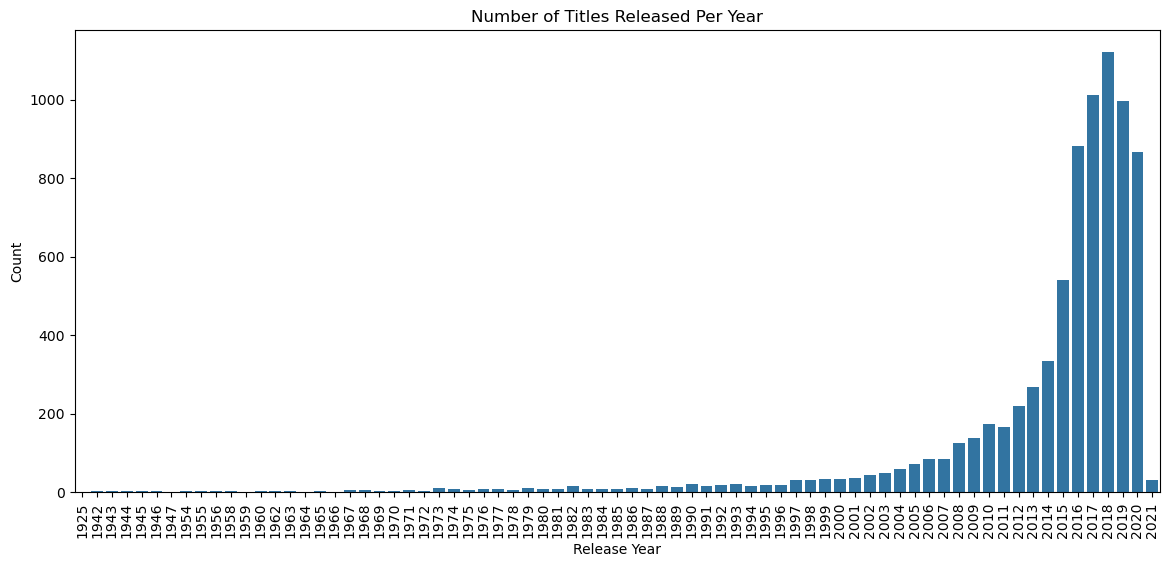

In [53]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=yearly_titles.index,
    y=yearly_titles.values
)

plt.xticks(rotation=90)

plt.title("Number of Titles Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

In [54]:
# Find Peak Production Year
peak_year = yearly_titles.idxmax()
peak_count = yearly_titles.max()

print("Peak Year:", peak_year)
print("Titles Released:", peak_count)

Peak Year: 2018
Titles Released: 1121


In [55]:
# Recent Trend (Last 10 Years)
recent_trend = (
    df_clean[df_clean['release_year'] >= 2010]
    ['release_year']
    .value_counts()
    .sort_index()
)

recent_trend

release_year
2010     173
2011     166
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

In [56]:
yearly_titles.tail(15)

release_year
2007      85
2008     125
2009     137
2010     173
2011     166
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

# Interpretation
## Key Findings
1. Netflix content production increased steadily from 2007 to 2018.
2. The most significant growth occurred between 2015 and 2018.
3. Content production peaked in 2018 with 1121 titles.
4. After 2018, the number of releases started declining.
5. The very low count in 2021 suggests the dataset was collected before the year was complete.

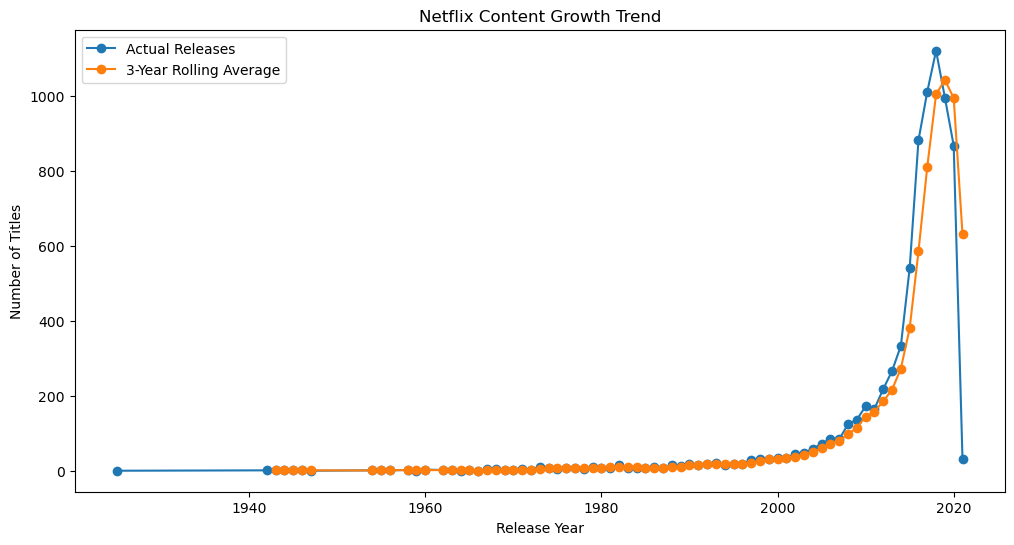

In [57]:
# Rolling Average Trend
yearly_df = yearly_titles.reset_index()
yearly_df.columns = ['Year','Count']

yearly_df['Rolling_Avg'] = yearly_df['Count'].rolling(3).mean()

plt.figure(figsize=(12,6))

plt.plot(
    yearly_df['Year'],
    yearly_df['Count'],
    marker='o',
    label='Actual Releases'
)

plt.plot(
    yearly_df['Year'],
    yearly_df['Rolling_Avg'],
    marker='o',
    label='3-Year Rolling Average'
)

plt.title("Netflix Content Growth Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()

plt.show()

# Task 6: Rating Analysis

## Questions
1. Most common maturity rating
2. Distribution of ratings
3. Visualization using countplots

In [58]:
## 1: Check Rating Distribution

In [59]:
df_clean['rating'].value_counts()

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [66]:
# 2: Top 10 ratings
rating_counts = df_clean['rating'].value_counts()

rating_counts

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [61]:
# 3: Most Common Rating
most_common_rating = df_clean['rating'].mode()[0]

print("Most Common Rating:", most_common_rating)

Most Common Rating: TV-MA


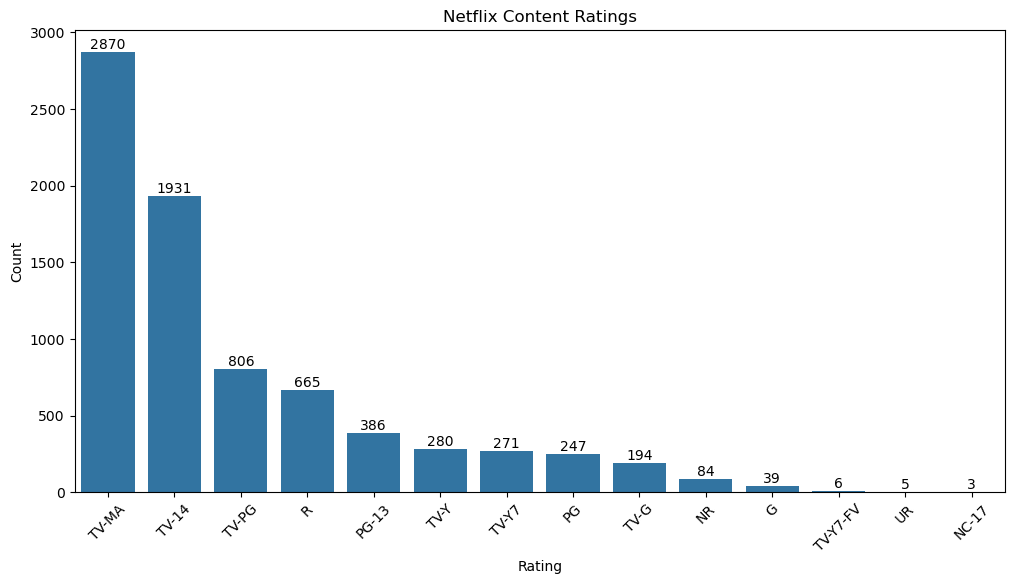

In [64]:
# 4: Countplot
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_clean,
    x='rating',
    order=df_clean['rating'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

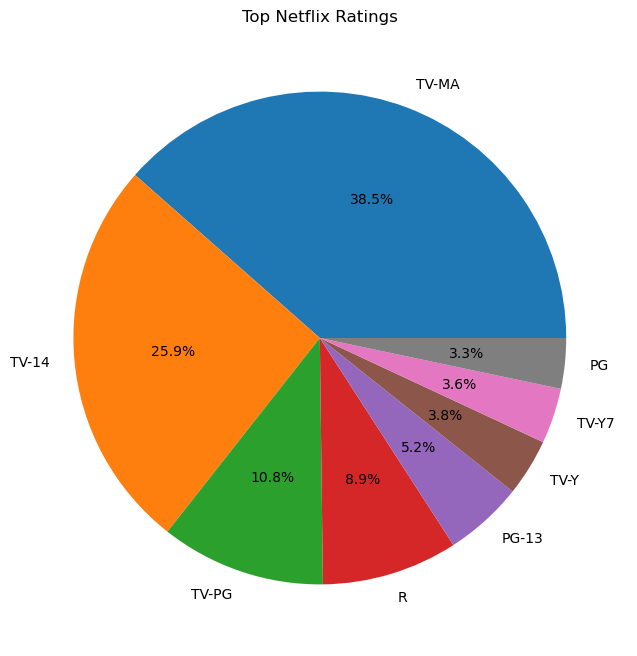

In [65]:
# Pie Chart
top_ratings = df_clean['rating'].value_counts().head(8)

plt.figure(figsize=(8,8))

plt.pie(
    top_ratings.values,
    labels=top_ratings.index,
    autopct='%1.1f%%'
)

plt.title("Top Netflix Ratings")

plt.show()

## Interpretation
### Key Findings
1. TV-MA is the most common rating with 2870 titles.
2. TV-14 is the second most frequent rating with 1931 titles.
3. Most Netflix content is intended for teenagers and adults.
4. Children's content (TV-Y, TV-Y7, TV-G) represents a much smaller portion of the catalog.
5. Mature content dominates the platform.

# Task 7: Genre Analysis 

## Questions: 
1. Top 10 genres.  
2. Most popular genre category.  
3. Visualize findings.

In [69]:
df_clean['genres'].head(10)

0    International TV Shows, TV Dramas, TV Sci-Fi &...
1       Horror Movies, International Movies, Thrillers
2          Dramas, International Movies, Sports Movies
3                                             Comedies
4    British TV Shows, Docuseries, Science & Nature TV
5                        Independent Movies, Thrillers
6                         Action & Adventure, Comedies
7          Dramas, Independent Movies, Romantic Movies
8      Comedies, International Movies, Romantic Movies
9                                        Documentaries
Name: genres, dtype: object

In [70]:
# 1: Split Multiple Genres
genre_series = (
    df_clean['genres']
    .str.split(',')
    .explode()
    .str.strip()
)

In [72]:
# 2: Count Genres
genre_counts = genre_series.value_counts()

genre_counts.head(10)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

In [73]:
# 3: Top 10 Genres
top10_genres = genre_counts.head(10)

print(top10_genres)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


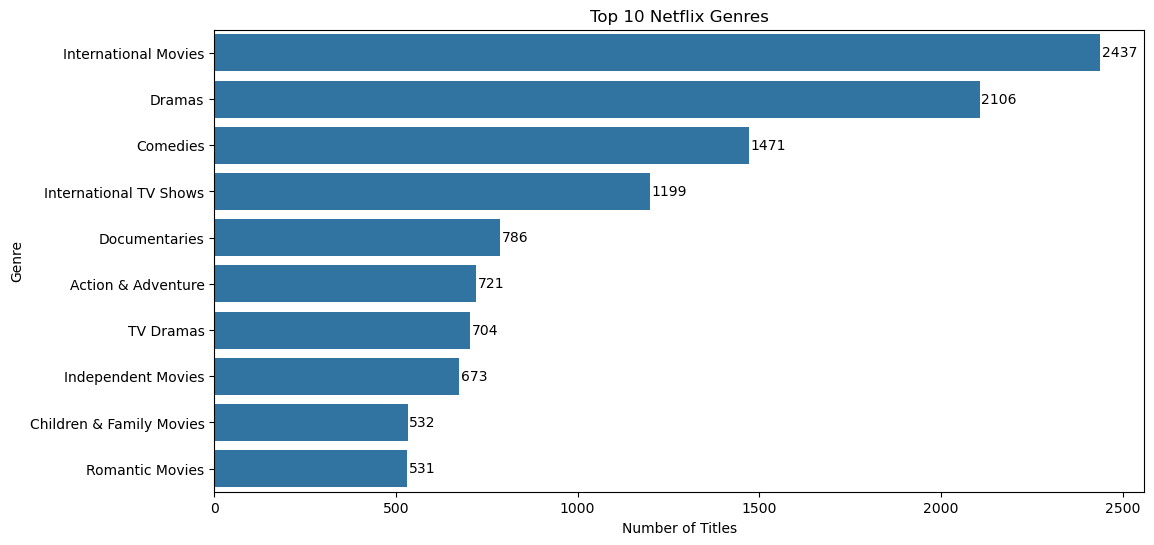

In [74]:
# 4: Horizontal Bar Chart
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_genres.values,
    y=top10_genres.index
)

for i, value in enumerate(top10_genres.values):
    ax.text(value + 5, i, str(value), va='center')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

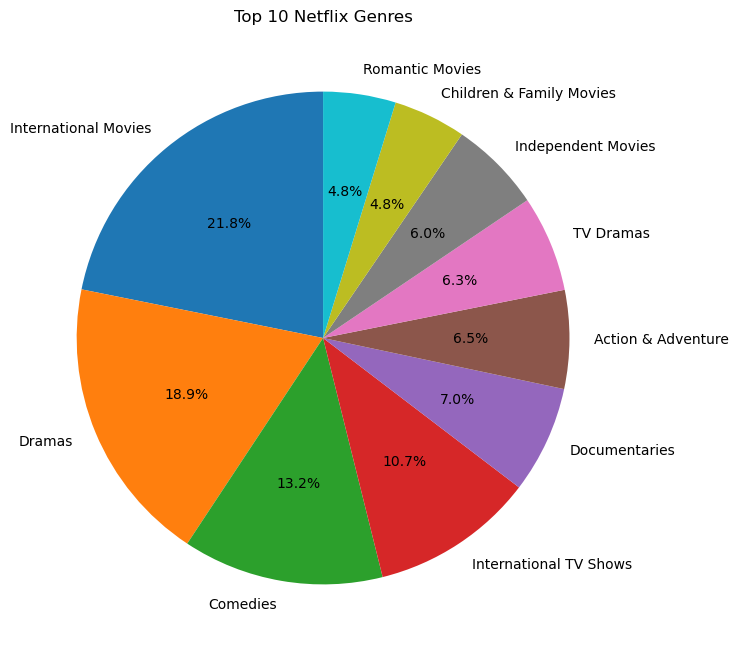

In [75]:
plt.figure(figsize=(8,8))

plt.pie(
    top10_genres.values,
    labels=top10_genres.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Top 10 Netflix Genres")

plt.show()

In [76]:
# 6: Most Popular Genre
print("Most Popular Genre:", genre_counts.idxmax())
print("Number of Titles:", genre_counts.max())

Most Popular Genre: International Movies
Number of Titles: 2437


In [77]:
# 7: Genre Percentage
genre_percentage = round(
    genre_counts / genre_counts.sum() * 100,
    2
)

genre_percentage.head(10)

genres
International Movies        14.28
Dramas                      12.34
Comedies                     8.62
International TV Shows       7.02
Documentaries                4.60
Action & Adventure           4.22
TV Dramas                    4.12
Independent Movies           3.94
Children & Family Movies     3.12
Romantic Movies              3.11
Name: count, dtype: float64

## Interpretation
### Key Findings
1. International Movies is the most popular genre with 2437 titles.
2. Dramas rank second with 2106 titles.
3. Comedies are the third most common genre.
4. Netflix has a strong focus on international content, showing its strategy of serving a global audience.
5. Documentary, Action & Adventure, and TV Dramas also make up a significant part of the library.

# Task 8: Duration Analysis 

## Questions: 
1. Average movie duration.  
2. Longest movie.  
3. Shortest movie.  
4. Distribution of movie duration.  
## Visualizations: 
• Histogram  
• Box Plot 

In [78]:
df_clean[['type', 'duration']].head(10)

,type,duration
0,TV Show,4
1,Movie,143
2,Movie,124
3,Movie,90
4,TV Show,1
5,Movie,90
6,Movie,94
7,Movie,112
8,Movie,129
9,Movie,85


In [80]:
# 1: Filter Movies
movies = df_clean[df_clean['type'] == 'Movie'].copy()

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,added_year,added_month,added_month_name,primary_country
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,December,India
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,January,Indonesia
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,March,United States
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",2019-02-25,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...,2019,2,February,United States
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",2021-01-01,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...,2021,1,January,Germany


In [81]:
# 2: Basic Statistics
movies['duration'].describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

In [82]:
# 3: Average Movie Duration
average_duration = movies['duration'].mean()

print("Average Movie Duration:", round(average_duration,2), "minutes")

Average Movie Duration: 99.31 minutes


In [83]:
# 4: Longest Movie
longest_movie = movies.loc[movies['duration'].idxmax()]

print(longest_movie[['title','duration']])

title       Black Mirror: Bandersnatch
duration                           312
Name: 7741, dtype: object


In [84]:
# 5: Shortest Movie
shortest_movie = movies.loc[movies['duration'].idxmin()]

print(shortest_movie[['title','duration']])

title       Silent
duration         3
Name: 5119, dtype: object


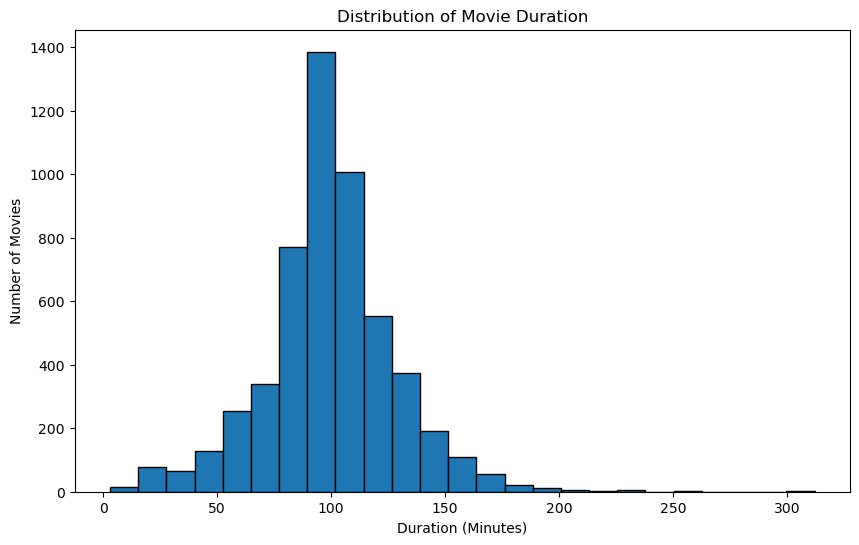

In [85]:
# 6: Histogram
plt.figure(figsize=(10,6))

plt.hist(
    movies['duration'],
    bins=25,
    edgecolor='black'
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

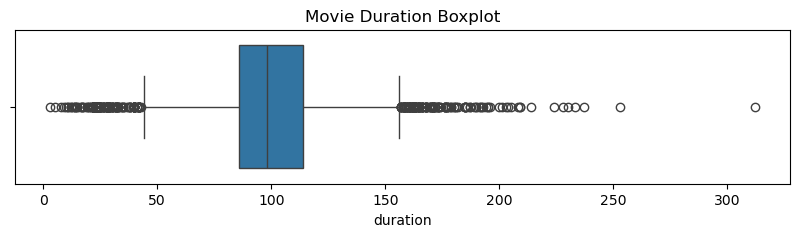

In [86]:
# 7: Box Plot
plt.figure(figsize=(10,2))

sns.boxplot(
    x=movies['duration']
)

plt.title("Movie Duration Boxplot")

plt.show()

## Duration Analysis
- The average movie duration is 99.31 minutes.
- The shortest movie  Silent has a duration of  3  minutes.
- The longest movie  Black Mirror: Bandersnatch has a duration of 312 minutes.
- Most movies fall within a moderate duration range, with only a few exceptionally short or long movies.

# Task 9: Outlier Analysis 

## Using movie duration: 
1. Detect outliers using IQR.  
2. Detect outliers using Z-score.  
3. Compare results. 

In [87]:
# 1: Calculate Quartiles
Q1 = movies['duration'].quantile(0.25)
Q3 = movies['duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

44.0 156.0


In [88]:
# Detect Outliers
iqr_outliers = movies[
    (movies['duration'] < lower) |
    (movies['duration'] > upper)
]

print("Number of IQR Outliers:", len(iqr_outliers))

Number of IQR Outliers: 337


In [89]:
# Z-Score Method
from scipy.stats import zscore

movies['z_score'] = zscore(movies['duration'])

In [90]:
# Detect Outliers
z_outliers = movies[
    movies['z_score'].abs() > 3
]

print("Number of Z-Score Outliers:", len(z_outliers))

Number of Z-Score Outliers: 45


In [91]:
# Compare Both Methods
print("IQR Outliers:", len(iqr_outliers))
print("Z-Score Outliers:", len(z_outliers))

IQR Outliers: 337
Z-Score Outliers: 45


## Interpretation
### Why the numbers are different
- IQR (337 outliers): Detects any movie whose duration lies outside the normal interquartile range. It is more sensitive and flags many unusually short or long movies.
- Z-Score (45 outliers): Only detects movies that are extremely far from the average (more than 3 standard deviations away). It is stricter and identifies only the most extreme cases.

This difference is normal and expected because the two methods use different statistical criteria.

# Task 10: Feature Engineering 

### Create: 
#### Release Decade 
- 1980s 
- 1990s 
- 2000s 
- 2010s 
- 2020s 
### Content Age 
Current Year - Release Year 
### Duration Category 
- Short 
- Medium 
- Long 
Analyze these new features. 

In [93]:
# 1: Release Decade
df_clean['Release Decade'] = pd.cut(
    df_clean['release_year'],
    bins=[1979, 1989, 1999, 2009, 2019, 2029],
    labels=['1980s', '1990s', '2000s', '2010s', '2020s']
)

df_clean['Release Decade'].value_counts().sort_index()

Release Decade
1980s     106
1990s     225
2000s     728
2010s    5711
2020s     899
Name: count, dtype: int64

In [94]:
# 2: Content Age
current_year = 2026

df_clean['Content Age'] = current_year - df_clean['release_year']

df_clean[['release_year', 'Content Age']].head()

,release_year,Content Age
0,2020,6
1,2008,18
2,2016,10
3,2016,10
4,2017,9


In [95]:
# 3: Duration Category
df_clean['Duration Category'] = pd.cut(
    df_clean['duration'],
    bins=[0, 60, 120, 400],
    labels=['Short', 'Medium', 'Long']
)

df_clean['Duration Category'].value_counts()

Duration Category
Medium    3920
Short     2856
Long      1011
Name: count, dtype: int64

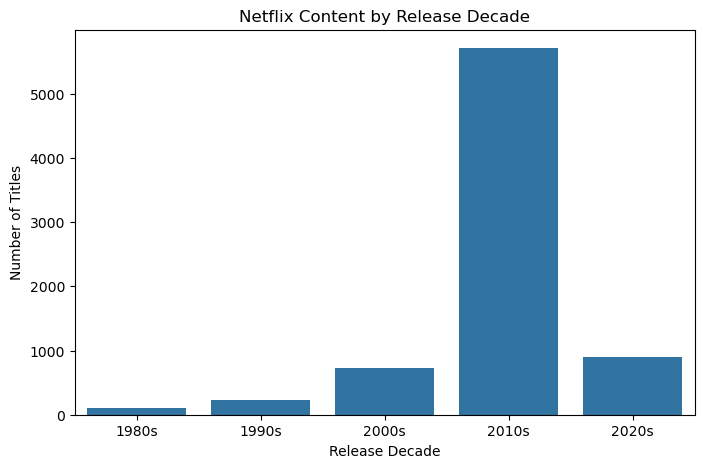

In [96]:
# 4: Visualize Release Decades
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='Release Decade',
    order=['1980s', '1990s', '2000s', '2010s', '2020s']
)

plt.title("Netflix Content by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")

plt.show()

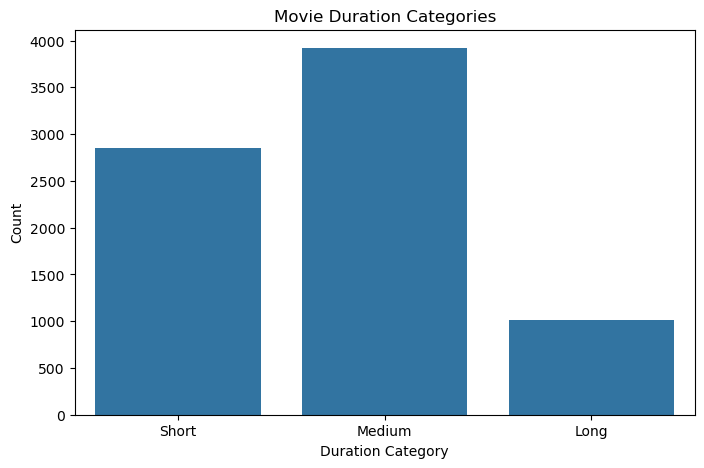

In [109]:
# 5: Visualize Duration Categories
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='Duration Category',
    order=['Short', 'Medium', 'Long']
)

plt.title("Movie Duration Categories")
plt.xlabel("Duration Category")
plt.ylabel("Count")

plt.show()

## Interpretation
- Medium-duration titles are the largest category, making up about 50.3% of the dataset.
- Short-duration content represents about 36.7%, including short films and TV shows with fewer seasons.
- Long-duration titles account for approximately 13%, indicating that very long content is relatively uncommon.

## Interpretation
- 2010s dominate the dataset with 5711 titles.
- This indicates Netflix experienced its biggest content expansion during the 2010s.
- The 2020s have fewer titles because the dataset contains only the early years of the decade.
- The platform has relatively fewer titles from the 1980s and 1990s, showing a stronger emphasis on modern content.

# Task 11: Multivariate Analysis 

## Task 11: Multivariate Analysis 
### Investigate: 
1. Country vs Content Type  
2. Year vs Content Type  
3. Rating vs Content Type  
### Use: 
• Crosstab  
• Heatmaps  
• GroupBy 

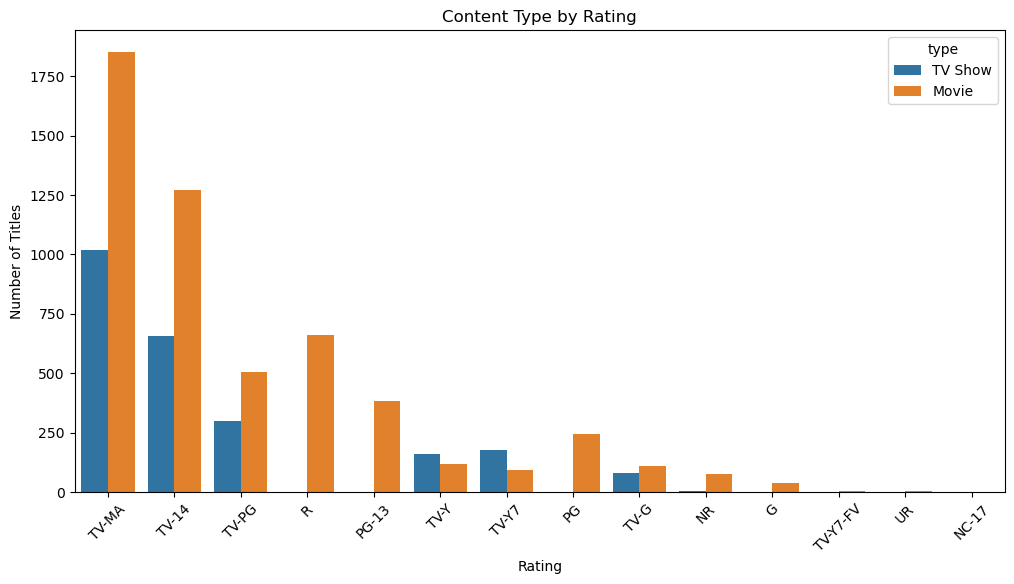

In [101]:
# 1. Content Type by Rating
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    x='rating',
    hue='type',
    order=df_clean['rating'].value_counts().index
)

plt.title("Content Type by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

## Interpretation
- Shows whether Movies or TV Shows dominate each maturity rating.
- Helps identify the target audience for different content types.

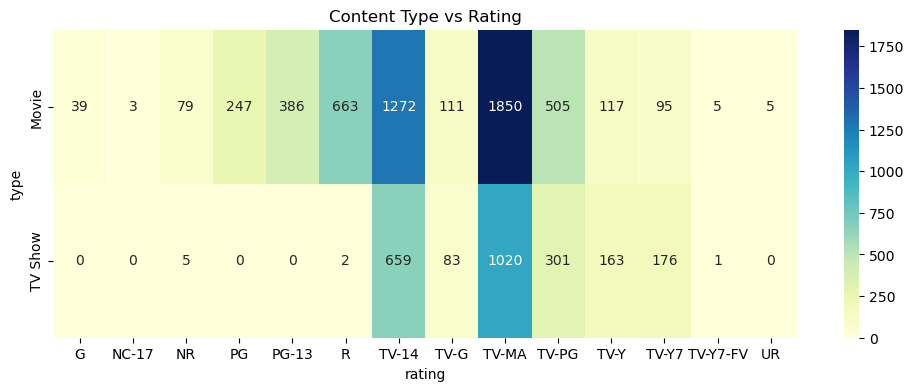

In [104]:
# 2. Heatmap: Type vs Ratin
rating_type = pd.crosstab(df_clean['type'], df_clean['rating'])

plt.figure(figsize=(12,4))

sns.heatmap(
    rating_type,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Content Type vs Rating")

plt.show()

### Interpretation
- Darker cells indicate higher concentrations.
- Makes comparisons easier than a standard table.

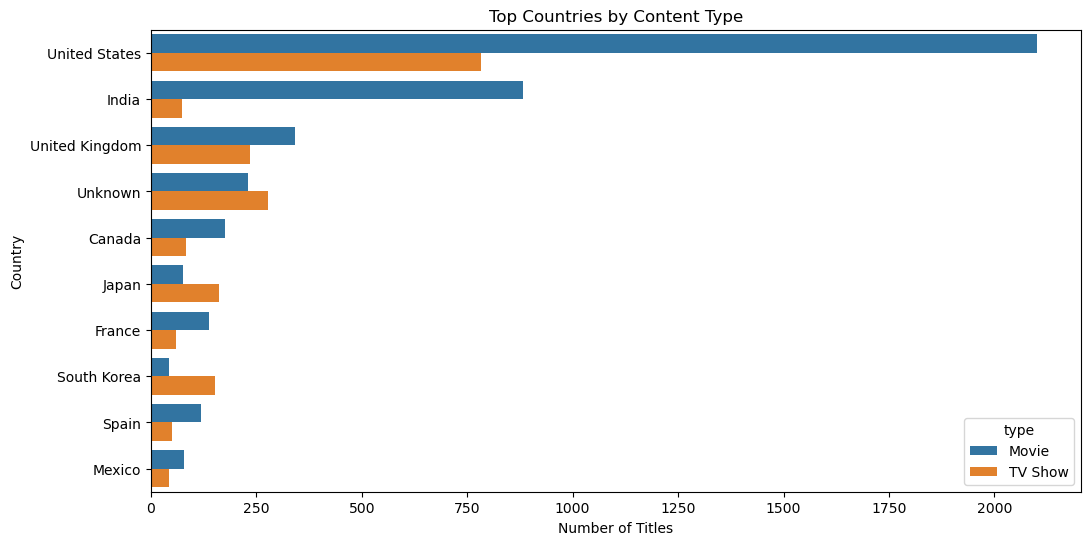

In [105]:
# 3. Top 10 Countries by Content Type
top10 = df_clean['primary_country'].value_counts().head(10).index

country_type = df_clean[
    df_clean['primary_country'].isin(top10)
]

plt.figure(figsize=(12,6))

sns.countplot(
    data=country_type,
    y='primary_country',
    hue='type',
    order=top10
)

plt.title("Top Countries by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

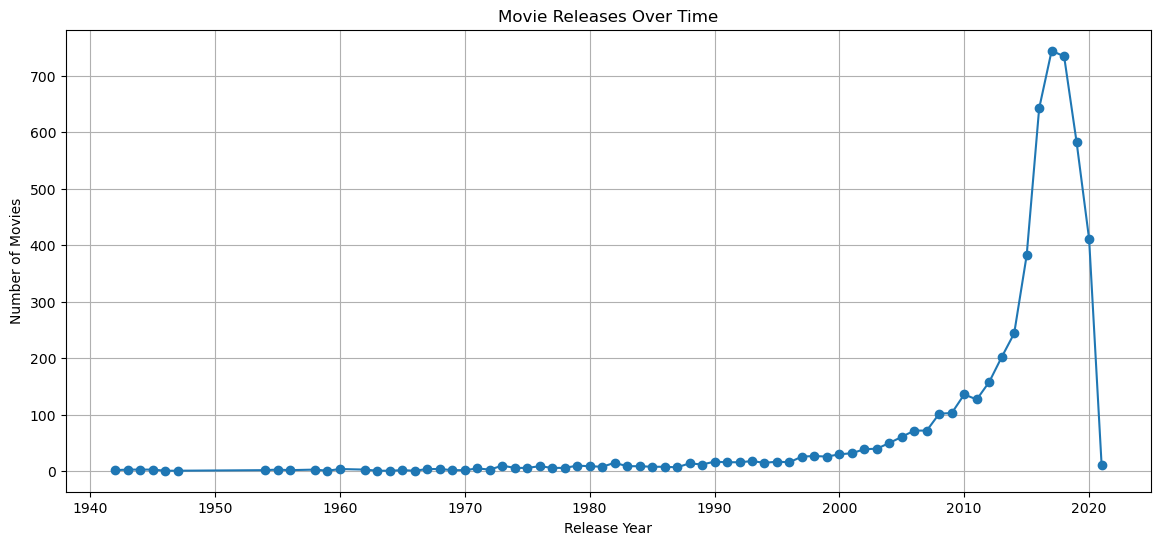

In [106]:
# 4. Movies Released Each Year
movies_only = df_clean[df_clean['type'] == 'Movie']

movie_year = (
    movies_only['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    movie_year.index,
    movie_year.values,
    marker='o'
)

plt.title("Movie Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.grid(True)

plt.show()

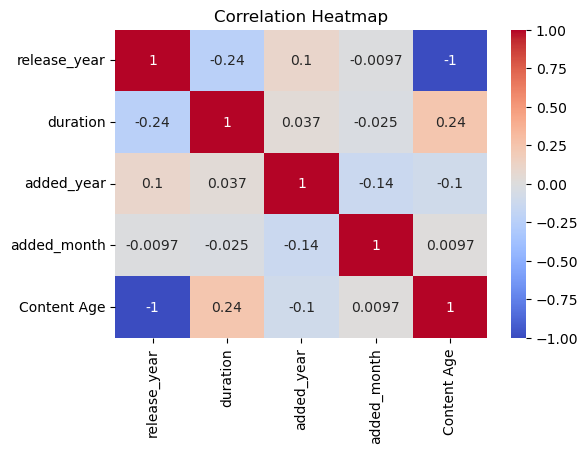

In [107]:
# 5. Correlation Heatmap (Numerical Features)
numeric_df = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Task 12: Business Insights 
## Provide: 5 Business Insights and 3 Strategic Recommendations for Netflix executives.

## 1. Movies dominate the Netflix catalog, making up 69.05% of all titles.
## 2. The United States is the leading content producer with 2883 titles, followed by India (956).
## 3. International Movies are the most common genre, highlighting Netflix's focus on global audiences.
## 4. 2018 was the peak release year with 1121 titles, reflecting Netflix's rapid content expansion.
## 5. The 2010s contain the largest number of releases (5711 titles), showing that Netflix's biggest growth occurred during this decade.
## 6. The average movie duration is 99.31 minutes, matching the standard length of feature films.
## 7. TV-MA is the most common rating, indicating that Netflix primarily targets adult viewers.
## 8. Most content falls into the Medium Duration category (3920 titles), suggesting a preference for standard-length entertainment.
## 9. Outlier analysis shows that while a few movies have exceptionally short or long durations, the majority follow a consistent duration pattern.

# Recommendations
## 1. Continue investing in international and regional content, as it represents one of Netflix's strongest categories.
## 2. Expand production in emerging markets to diversify the content library further.
## 3. Maintain a strong portfolio of Drama and Comedy, as these genres consistently attract viewers.
## 4. Increase the availability of family-friendly content to broaden the audience base.
## 5. Continue producing feature-length movies while experimenting selectively with shorter and longer formats based on audience demand.
## 6. Use viewing analytics to optimize future investments in genres and ratings that drive the highest engagement.